In [1]:
import os
import pandas as pd
import numpy as np
import csv
import time
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from scipy.stats import pearsonr
import seaborn as sns
import pybaseball as bb
import datetime
from pybaseball import statcast_pitcher_percentile_ranks
from pybaseball import statcast_pitcher_spin_dir_comp
from pybaseball import statcast_pitcher_arsenal_stats
import requests
import json
from typing import Dict, Any, Optional, List, Union
from datetime import datetime, timedelta
from concurrent.futures import ThreadPoolExecutor, as_completed

In [ ]:
# Get Aaron Judge's MLBAM ID
judge_id = bb.playerid_lookup('judge', 'aaron')['key_mlbam'][0]
judge_id

# Define 2025 MLB Season
start_date = "2025-03-20"
end_date = "2025-10-05"

# Get Statcast pitch-by-pitch data for Aaron Judge as a batter in the 2025 season
judge_batting_data_2025 = bb.statcast_batter(start_dt=start_date, end_dt=end_date, player_id=judge_id)
judge_batting_data_2025.head()

Gathering player lookup table. This may take a moment.
Gathering Player Data


,pitch_type,game_date,release_speed,release_pos_x,release_pos_z,player_name,batter,pitcher,events,description,...,batter_days_until_next_game,api_break_z_with_gravity,api_break_x_arm,api_break_x_batter_in,arm_angle,attack_angle,attack_direction,swing_path_tilt,intercept_ball_minus_batter_pos_x_inches,intercept_ball_minus_batter_pos_y_inches
0,FF,2025-10-05,94.2,-0.60,7.09,"Judge, Aaron",592450,702056,strikeout,swinging_strike,...,2.0,1.01,0.36,0.36,62.9,17.575787,-5.727006,25.722115,37.841174,18.543551
1,SL,2025-10-05,88.1,-0.50,7.11,"Judge, Aaron",592450,702056,NaN,ball,...,2.0,2.58,0.34,0.34,63.8,NaN,NaN,NaN,NaN,NaN
2,SL,2025-10-05,89.5,-0.51,7.17,"Judge, Aaron",592450,702056,NaN,foul_tip,...,2.0,2.48,0.52,0.52,64.7,19.217557,-9.433847,40.527443,28.923275,24.706599
3,FF,2025-10-05,94.7,-0.30,7.03,"Judge, Aaron",592450,702056,NaN,ball,...,2.0,0.99,0.29,0.29,64.1,NaN,NaN,NaN,NaN,NaN
4,FS,2025-10-05,83.2,-0.36,7.18,"Judge, Aaron",592450,702056,NaN,ball,...,2.0,2.43,1.03,1.03,69.9,NaN,NaN,NaN,NaN,NaN


In [3]:
# Create a dataframe for plate appearances vs right-handed pitchers
judge_vs_rhp = judge_batting_data_2025[judge_batting_data_2025['p_throws'] == 'R'].copy()

 
#judge_vs_rhp.head()

arm_angle_stats = judge_vs_rhp['arm_angle'].agg(['count', 'min', 'max', 'mean', 'std'])
arm_angle_stats['range'] = arm_angle_stats['max'] - arm_angle_stats['min']
print("Arm Angle Summary Statistics (judge_vs_rhp):")
print(arm_angle_stats)

Arm Angle Summary Statistics (judge_vs_rhp):
count    2110.000000
min        -8.800000
max        74.500000
mean       38.058104
std        11.962418
range      83.300000
Name: arm_angle, dtype: float64


In [4]:
judge_vs_rhp['events'].value_counts()

events
field_out                    142
strikeout                    128
single                        79
walk                          78
home_run                      37
double                        23
intent_walk                   14
grounded_into_double_play     10
force_out                      9
hit_by_pitch                   8
sac_fly                        7
strikeout_double_play          2
triple                         2
fielders_choice                1
field_error                    1
Name: count, dtype: int64

In [5]:
# Create a dataframe for plate appearances vs left-handed pitchers
judge_vs_lhp = judge_batting_data_2025[judge_batting_data_2025['p_throws'] == 'L'].copy()  

#judge_vs_lhp.head()

arm_angle_stats_lhp = judge_vs_lhp['arm_angle'].agg(['count', 'min', 'max', 'mean', 'std'])
arm_angle_stats_lhp['range'] = arm_angle_stats_lhp['max'] - arm_angle_stats_lhp['min']
print("Arm Angle Summary Statistics (judge_vs_lhp):")
print(arm_angle_stats_lhp)

Arm Angle Summary Statistics (judge_vs_lhp):
count    599.000000
min       -9.600000
max       66.900000
mean      38.374958
std       12.023319
range     76.500000
Name: arm_angle, dtype: float64


In [27]:
# Create a dataframe for plate appearances vs left-handed pitchers
judge_vs_rhp = judge_batting_data_2025[judge_batting_data_2025['p_throws'] == 'R'].copy()  

#judge_vs_lhp.head()

arm_angle_stats_rhp = judge_vs_rhp['arm_angle'].agg(['count', 'min', 'max', 'mean', 'std'])
arm_angle_stats_rhp['range'] = arm_angle_stats_rhp['max'] - arm_angle_stats_rhp['min']
print("Arm Angle Summary Statistics (judge_vs_lhp):")
print(arm_angle_stats_rhp)

Arm Angle Summary Statistics (judge_vs_lhp):
count    2110.000000
min        -8.800000
max        74.500000
mean       38.058104
std        11.962418
range      83.300000
Name: arm_angle, dtype: float64


In [6]:
judge_vs_lhp['events'].value_counts()

events
strikeout                    39
field_out                    38
single                       22
intent_walk                  22
home_run                     17
walk                         15
double                        8
grounded_into_double_play     6
force_out                     3
sac_fly                       1
Name: count, dtype: int64

In [28]:
judge_vs_rhp['events'].value_counts()

events
field_out                    142
strikeout                    128
single                        79
walk                          78
home_run                      37
double                        23
intent_walk                   14
grounded_into_double_play     10
force_out                      9
hit_by_pitch                   8
sac_fly                        7
strikeout_double_play          2
triple                         2
fielders_choice                1
field_error                    1
Name: count, dtype: int64

In [19]:
# Define the bins and labels for arm angle
arm_angle_bins_custom = [-float('inf'), 20, 30, 40, 50, float('inf')]

judge_vs_lhp['arm_angle_bin'] = pd.cut(judge_vs_lhp['arm_angle'], bins=arm_angle_bins_custom, right=False)

# Count occurrences of each bin
arm_angle_counts_lhp = judge_vs_lhp['arm_angle_bin'].value_counts().sort_index()

arm_angle_counts_lhp

arm_angle_bin
[-inf, 20.0)     35
[20.0, 30.0)    114
[30.0, 40.0)    177
[40.0, 50.0)    158
[50.0, inf)     115
Name: count, dtype: int64

In [29]:
judge_vs_rhp['arm_angle_bin'] = pd.cut(judge_vs_rhp['arm_angle'], bins=arm_angle_bins_custom, right=False)

# Count occurrences of each bin
arm_angle_counts_rhp = judge_vs_rhp['arm_angle_bin'].value_counts().sort_index()

arm_angle_counts_rhp

arm_angle_bin
[-inf, 20.0)    132
[20.0, 30.0)    367
[30.0, 40.0)    710
[40.0, 50.0)    556
[50.0, inf)     345
Name: count, dtype: int64

In [20]:
# Bin 'arm_angle' values by width 5 for judge_vs_lhp
#bin_width = 5
#judge_vs_lhp['arm_angle_bin'] = pd.cut(judge_vs_lhp['arm_angle'], bins=range(int(judge_vs_lhp['arm_angle'].min()) - bin_width, int(judge_vs_lhp['arm_angle'].max()) + bin_width, bin_width), right=False)

# Count occurrences of each bin
#arm_angle_counts_lhp = judge_vs_lhp['arm_angle_bin'].value_counts().sort_index()

#arm_angle_counts_lhp

/var/folders/qy/r76kf66n2bs673t7b5svdlf80000gp/T/ipykernel_34660/3868602334.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  arm_angle_event_counts_lhp = judge_vs_lhp.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)


Text(0, 0.5, 'Count')

<Figure size 1200x800 with 0 Axes>

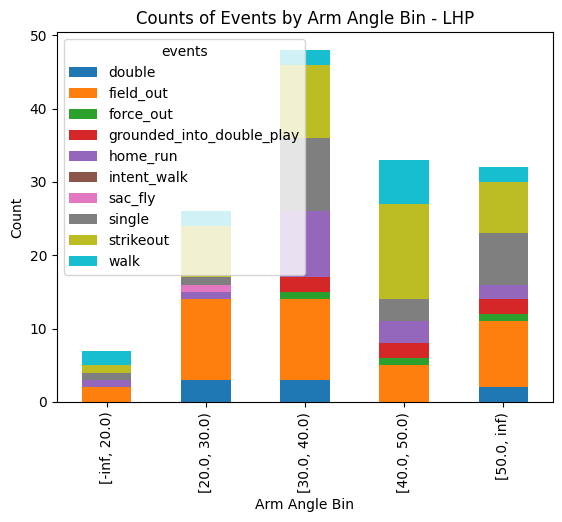

In [ ]:
# Group by 'arm_angle_bin' and 'events', then count the occurrences
arm_angle_event_counts_lhp = judge_vs_lhp.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
arm_angle_event_counts_lhp
# Create a bar plot of the counts
plt.figure(figsize=(12, 8))
arm_angle_event_counts_lhp.plot(kind='bar', stacked=True)
plt.title('Counts of Events by Arm Angle Bin - LHP')
plt.xlabel('Arm Angle Bin')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

In [1]:
# Group by 'arm_angle_bin' and 'events', then count the occurrences
arm_angle_event_counts_rhp = judge_vs_rhp.groupby(['arm_angle_bin', 'events']).size().unstack(fill_value=0)
arm_angle_event_counts_rhp
# Create a bar plot of the counts
plt.figure(figsize=(12, 8))
arm_angle_event_counts_rhp.plot(kind='bar', stacked=True)
plt.title('Counts of Events by Arm Angle Bin - RHP')
plt.xlabel('Arm Angle Bin')
plt.ylabel('Count')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)

NameError: name 'judge_vs_rhp' is not defined

In [22]:
arm_angle_event_counts_lhp

events,double,field_out,force_out,grounded_into_double_play,home_run,intent_walk,sac_fly,single,strikeout,walk
arm_angle_bin,,,,,,,,,,
"[-inf, 20.0)",0,2,0,0,1,0,0,1,1,2
"[20.0, 30.0)",3,11,0,0,1,0,1,1,7,2
"[30.0, 40.0)",3,11,1,2,9,0,0,10,10,2
"[40.0, 50.0)",0,5,1,2,3,0,0,3,13,6
"[50.0, inf)",2,9,1,2,2,0,0,7,7,2


In [33]:
arm_angle_event_counts_rhp

events,double,field_error,field_out,fielders_choice,force_out,grounded_into_double_play,hit_by_pitch,home_run,intent_walk,sac_fly,single,strikeout,strikeout_double_play,triple,walk
arm_angle_bin,,,,,,,,,,,,,,,
"[-inf, 20.0)",2,0,10,0,1,0,0,2,0,0,7,6,1,0,3
"[20.0, 30.0)",4,1,29,0,1,2,2,8,0,1,12,16,0,1,19
"[30.0, 40.0)",8,0,39,1,3,1,1,12,0,1,23,46,0,0,28
"[40.0, 50.0)",6,0,39,0,1,1,2,11,0,2,26,38,1,1,12
"[50.0, inf)",3,0,23,0,3,6,3,4,0,2,11,18,0,0,13


In [23]:
# Ensure all columns from judge_batting_data_2025['events'] are present in arm_angle_event_counts_lhp (add with 0s if missing)
all_events = judge_batting_data_2025['events'].unique()
# Ensure all columns from all_events are present in arm_angle_event_counts_lhp (add missing ones, fill with 0)
for event in all_events:
    if event not in arm_angle_event_counts_lhp.columns:
        arm_angle_event_counts_lhp[event] = 0
# Reorder columns to match all_events order
arm_angle_event_counts_lhp = arm_angle_event_counts_lhp.reindex(columns=all_events, fill_value=0)
arm_angle_event_counts_lhp

events,strikeout,NaN,walk,single,field_out,double,hit_by_pitch,home_run,intent_walk,grounded_into_double_play,force_out,sac_fly,fielders_choice,strikeout_double_play,triple,field_error
arm_angle_bin,,,,,,,,,,,,,,,,
"[-inf, 20.0)",1,0,2,1,2,0,0,1,0,0,0,0,0,0,0,0
"[20.0, 30.0)",7,0,2,1,11,3,0,1,0,0,0,1,0,0,0,0
"[30.0, 40.0)",10,0,2,10,11,3,0,9,0,2,1,0,0,0,0,0
"[40.0, 50.0)",13,0,6,3,5,0,0,3,0,2,1,0,0,0,0,0
"[50.0, inf)",7,0,2,7,9,2,0,2,0,2,1,0,0,0,0,0


In [34]:
# Ensure all columns from judge_batting_data_2025['events'] are present in arm_angle_event_counts_lhp (add with 0s if missing)
all_events = judge_batting_data_2025['events'].unique()
# Ensure all columns from all_events are present in arm_angle_event_counts_lhp (add missing ones, fill with 0)
for event in all_events:
    if event not in arm_angle_event_counts_rhp.columns:
        arm_angle_event_counts_rhp[event] = 0
# Reorder columns to match all_events order
arm_angle_event_counts_rhp = arm_angle_event_counts_rhp.reindex(columns=all_events, fill_value=0)
arm_angle_event_counts_rhp

events,strikeout,NaN,walk,single,field_out,double,hit_by_pitch,home_run,intent_walk,grounded_into_double_play,force_out,sac_fly,fielders_choice,strikeout_double_play,triple,field_error
arm_angle_bin,,,,,,,,,,,,,,,,
"[-inf, 20.0)",6,0,3,7,10,2,0,2,0,0,1,0,0,1,0,0
"[20.0, 30.0)",16,0,19,12,29,4,2,8,0,2,1,1,0,0,1,1
"[30.0, 40.0)",46,0,28,23,39,8,1,12,0,1,3,1,1,0,0,0
"[40.0, 50.0)",38,0,12,26,39,6,2,11,0,1,1,2,0,1,1,0
"[50.0, inf)",18,0,13,11,23,3,3,4,0,6,3,2,0,0,0,0


In [24]:
# Create a copy so that we don't overwrite the original
arm_angle_event_counts_lhp_ba = arm_angle_event_counts_lhp.copy()

# Calculate numerator: hits (single, double, triple, home_run)
hits_cols = ['single', 'double', 'triple', 'home_run']

arm_angle_event_counts_lhp_ba['hits'] = arm_angle_event_counts_lhp_ba[hits_cols].sum(axis=1)

arm_angle_event_counts_lhp_ba['Batting_Average'] = arm_angle_event_counts_lhp_ba['hits'] / (arm_angle_event_counts_lhp_ba['field_out'] + arm_angle_event_counts_lhp_ba['strikeout'] + arm_angle_event_counts_lhp_ba['grounded_into_double_play'] + arm_angle_event_counts_lhp_ba['force_out'] + arm_angle_event_counts_lhp_ba['field_error'] + arm_angle_event_counts_lhp_ba['fielders_choice'] + arm_angle_event_counts_lhp_ba['hits'] + arm_angle_event_counts_lhp_ba['strikeout_double_play'])

arm_angle_event_counts_lhp_ba['Slugging_Percentage'] = ((arm_angle_event_counts_lhp_ba['home_run'] * 4) + (arm_angle_event_counts_lhp_ba['double'] * 2) + (arm_angle_event_counts_lhp_ba['triple'] * 3) + (arm_angle_event_counts_lhp_ba['single'] * 1)) / (arm_angle_event_counts_lhp_ba['field_out'] + arm_angle_event_counts_lhp_ba['strikeout'] + arm_angle_event_counts_lhp_ba['grounded_into_double_play'] + arm_angle_event_counts_lhp_ba['force_out'] + arm_angle_event_counts_lhp_ba['field_error'] + arm_angle_event_counts_lhp_ba['fielders_choice'] + arm_angle_event_counts_lhp_ba['hits'] + arm_angle_event_counts_lhp_ba['strikeout_double_play'])

arm_angle_event_counts_lhp_ba['On_Base_Percentage'] = (arm_angle_event_counts_lhp_ba['hits'] + arm_angle_event_counts_lhp_ba['walk'] + arm_angle_event_counts_lhp_ba['hit_by_pitch'] + arm_angle_event_counts_lhp_ba['intent_walk'] ) / (arm_angle_event_counts_lhp_ba['field_out'] + arm_angle_event_counts_lhp_ba['strikeout'] + arm_angle_event_counts_lhp_ba['grounded_into_double_play'] + arm_angle_event_counts_lhp_ba['force_out'] + arm_angle_event_counts_lhp_ba['field_error'] + arm_angle_event_counts_lhp_ba['fielders_choice'] + arm_angle_event_counts_lhp_ba['hits'] + arm_angle_event_counts_lhp_ba['strikeout_double_play'])

arm_angle_event_counts_lhp_ba['On_Base_Plus_Slugging'] = arm_angle_event_counts_lhp_ba['On_Base_Percentage'] + arm_angle_event_counts_lhp_ba['Slugging_Percentage']

arm_angle_event_counts_lhp_ba['K_Rate'] = ((arm_angle_event_counts_lhp_ba['strikeout'] + arm_angle_event_counts_lhp_ba['strikeout_double_play']) / (arm_angle_event_counts_lhp_ba['field_out'] + arm_angle_event_counts_lhp_ba['strikeout'] + arm_angle_event_counts_lhp_ba['grounded_into_double_play'] + arm_angle_event_counts_lhp_ba['force_out'] + arm_angle_event_counts_lhp_ba['field_error'] + arm_angle_event_counts_lhp_ba['fielders_choice'] + arm_angle_event_counts_lhp_ba['hits'] + arm_angle_event_counts_lhp_ba['strikeout_double_play']))

arm_angle_event_counts_lhp_ba['BB_Rate'] = ((arm_angle_event_counts_lhp_ba['walk'] + arm_angle_event_counts_lhp_ba['hit_by_pitch'] + arm_angle_event_counts_lhp_ba['intent_walk']) / (arm_angle_event_counts_lhp_ba['field_out'] + arm_angle_event_counts_lhp_ba['strikeout'] + arm_angle_event_counts_lhp_ba['grounded_into_double_play'] + arm_angle_event_counts_lhp_ba['force_out'] + arm_angle_event_counts_lhp_ba['field_error'] + arm_angle_event_counts_lhp_ba['fielders_choice'] + arm_angle_event_counts_lhp_ba['hits'] + arm_angle_event_counts_lhp_ba['strikeout_double_play']))


In [35]:
# Create a copy so that we don't overwrite the original
arm_angle_event_counts_rhp_ba = arm_angle_event_counts_rhp.copy()

# Calculate numerator: hits (single, double, triple, home_run)
hits_cols = ['single', 'double', 'triple', 'home_run']

arm_angle_event_counts_rhp_ba['hits'] = arm_angle_event_counts_rhp_ba[hits_cols].sum(axis=1)

arm_angle_event_counts_rhp_ba['Batting_Average'] = arm_angle_event_counts_rhp_ba['hits'] / (arm_angle_event_counts_rhp_ba['field_out'] + arm_angle_event_counts_rhp_ba['strikeout'] + arm_angle_event_counts_rhp_ba['grounded_into_double_play'] + arm_angle_event_counts_rhp_ba['force_out'] + arm_angle_event_counts_rhp_ba['field_error'] + arm_angle_event_counts_rhp_ba['fielders_choice'] + arm_angle_event_counts_rhp_ba['hits'] + arm_angle_event_counts_rhp_ba['strikeout_double_play'])

arm_angle_event_counts_rhp_ba['Slugging_Percentage'] = ((arm_angle_event_counts_rhp_ba['home_run'] * 4) + (arm_angle_event_counts_rhp_ba['double'] * 2) + (arm_angle_event_counts_rhp_ba['triple'] * 3) + (arm_angle_event_counts_rhp_ba['single'] * 1)) / (arm_angle_event_counts_rhp_ba['field_out'] + arm_angle_event_counts_rhp_ba['strikeout'] + arm_angle_event_counts_rhp_ba['grounded_into_double_play'] + arm_angle_event_counts_rhp_ba['force_out'] + arm_angle_event_counts_rhp_ba['field_error'] + arm_angle_event_counts_rhp_ba['fielders_choice'] + arm_angle_event_counts_rhp_ba['hits'] + arm_angle_event_counts_rhp_ba['strikeout_double_play'])

arm_angle_event_counts_rhp_ba['On_Base_Percentage'] = (arm_angle_event_counts_rhp_ba['hits'] + arm_angle_event_counts_rhp_ba['walk'] + arm_angle_event_counts_rhp_ba['hit_by_pitch'] + arm_angle_event_counts_rhp_ba['intent_walk'] ) / (arm_angle_event_counts_rhp_ba['field_out'] + arm_angle_event_counts_rhp_ba['strikeout'] + arm_angle_event_counts_rhp_ba['grounded_into_double_play'] + arm_angle_event_counts_rhp_ba['force_out'] + arm_angle_event_counts_rhp_ba['field_error'] + arm_angle_event_counts_rhp_ba['fielders_choice'] + arm_angle_event_counts_rhp_ba['hits'] + arm_angle_event_counts_rhp_ba['strikeout_double_play'])

arm_angle_event_counts_rhp_ba['On_Base_Plus_Slugging'] = arm_angle_event_counts_rhp_ba['On_Base_Percentage'] + arm_angle_event_counts_rhp_ba['Slugging_Percentage']

arm_angle_event_counts_rhp_ba['K_Rate'] = ((arm_angle_event_counts_rhp_ba['strikeout'] + arm_angle_event_counts_rhp_ba['strikeout_double_play']) / (arm_angle_event_counts_rhp_ba['field_out'] + arm_angle_event_counts_rhp_ba['strikeout'] + arm_angle_event_counts_rhp_ba['grounded_into_double_play'] + arm_angle_event_counts_rhp_ba['force_out'] + arm_angle_event_counts_rhp_ba['field_error'] + arm_angle_event_counts_rhp_ba['fielders_choice'] + arm_angle_event_counts_rhp_ba['hits'] + arm_angle_event_counts_rhp_ba['strikeout_double_play']))

arm_angle_event_counts_rhp_ba['BB_Rate'] = ((arm_angle_event_counts_rhp_ba['walk'] + arm_angle_event_counts_rhp_ba['hit_by_pitch'] + arm_angle_event_counts_rhp_ba['intent_walk']) / (arm_angle_event_counts_rhp_ba['field_out'] + arm_angle_event_counts_rhp_ba['strikeout'] + arm_angle_event_counts_rhp_ba['grounded_into_double_play'] + arm_angle_event_counts_rhp_ba['force_out'] + arm_angle_event_counts_rhp_ba['field_error'] + arm_angle_event_counts_rhp_ba['fielders_choice'] + arm_angle_event_counts_rhp_ba['hits'] + arm_angle_event_counts_rhp_ba['strikeout_double_play']))

In [25]:
arm_angle_event_counts_lhp_ba

events,strikeout,NaN,walk,single,field_out,double,hit_by_pitch,home_run,intent_walk,grounded_into_double_play,...,strikeout_double_play,triple,field_error,hits,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",1,0,2,1,2,0,0,1,0,0,...,0,0,0,2,0.400000,1.000000,0.800000,1.800000,0.200000,0.400000
"[20.0, 30.0)",7,0,2,1,11,3,0,1,0,0,...,0,0,0,5,0.217391,0.478261,0.304348,0.782609,0.304348,0.086957
"[30.0, 40.0)",10,0,2,10,11,3,0,9,0,2,...,0,0,0,22,0.478261,1.130435,0.521739,1.652174,0.217391,0.043478
"[40.0, 50.0)",13,0,6,3,5,0,0,3,0,2,...,0,0,0,6,0.222222,0.555556,0.444444,1.000000,0.481481,0.222222
"[50.0, inf)",7,0,2,7,9,2,0,2,0,2,...,0,0,0,11,0.366667,0.633333,0.433333,1.066667,0.233333,0.066667


In [36]:
arm_angle_event_counts_lhp_ba

events,strikeout,NaN,walk,single,field_out,double,hit_by_pitch,home_run,intent_walk,grounded_into_double_play,...,strikeout_double_play,triple,field_error,hits,Batting_Average,Slugging_Percentage,On_Base_Percentage,On_Base_Plus_Slugging,K_Rate,BB_Rate
arm_angle_bin,,,,,,,,,,,,,,,,,,,,,
"[-inf, 20.0)",1,0,2,1,2,0,0,1,0,0,...,0,0,0,2,0.400000,1.000000,0.800000,1.800000,0.200000,0.400000
"[20.0, 30.0)",7,0,2,1,11,3,0,1,0,0,...,0,0,0,5,0.217391,0.478261,0.304348,0.782609,0.304348,0.086957
"[30.0, 40.0)",10,0,2,10,11,3,0,9,0,2,...,0,0,0,22,0.478261,1.130435,0.521739,1.652174,0.217391,0.043478
"[40.0, 50.0)",13,0,6,3,5,0,0,3,0,2,...,0,0,0,6,0.222222,0.555556,0.444444,1.000000,0.481481,0.222222
"[50.0, inf)",7,0,2,7,9,2,0,2,0,2,...,0,0,0,11,0.366667,0.633333,0.433333,1.066667,0.233333,0.066667


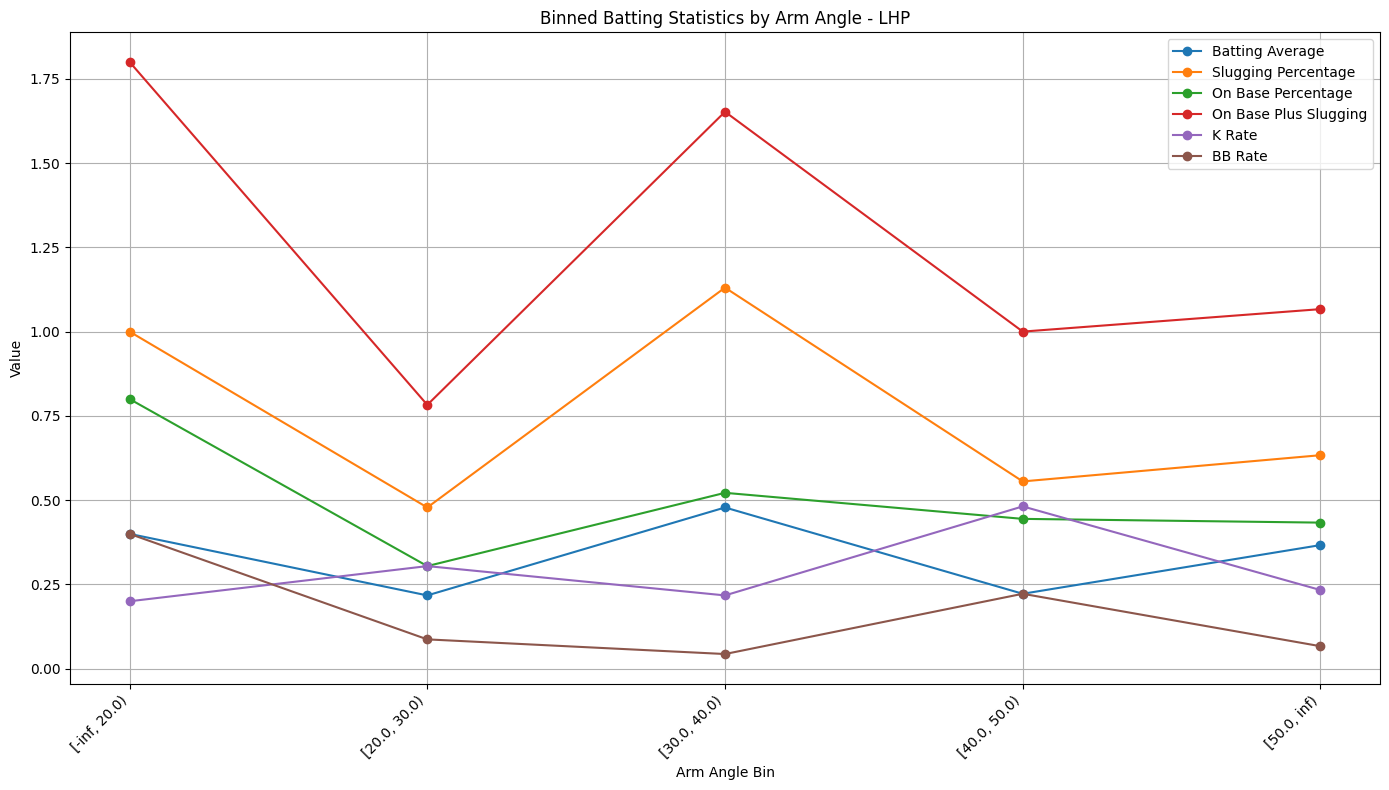

In [37]:
import matplotlib.pyplot as plt

# Select the statistics to plot
stats_to_plot = ['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage', 'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']
arm_angle_bins = arm_angle_event_counts_lhp_ba.index.astype(str)

plt.figure(figsize=(14, 8))
for stat in stats_to_plot:
    plt.plot(arm_angle_bins, arm_angle_event_counts_lhp_ba[stat], marker='o', label=stat.replace('_', ' '))

plt.xlabel("Arm Angle Bin")
plt.ylabel("Value")
plt.title("Binned Batting Statistics by Arm Angle - LHP")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

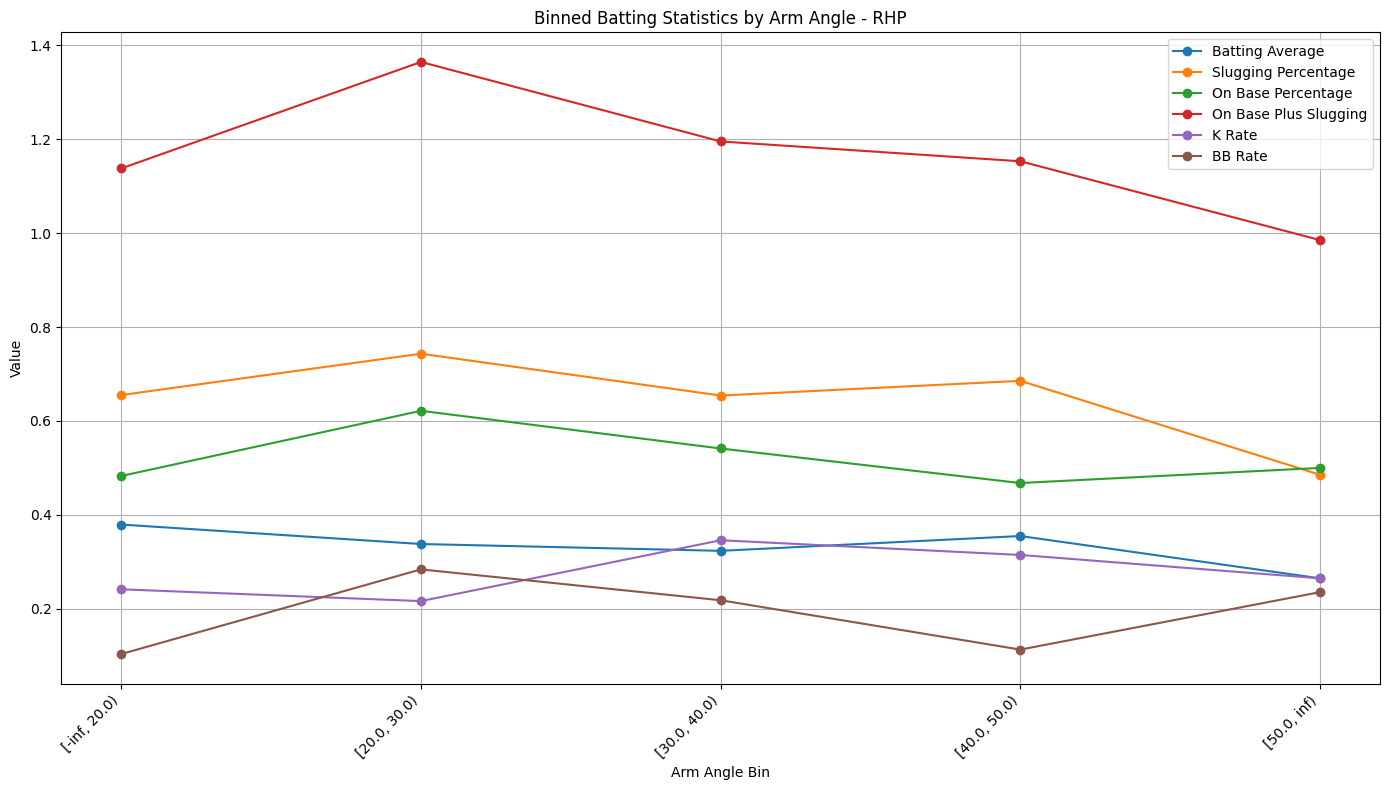

In [38]:
import matplotlib.pyplot as plt

# Select the statistics to plot
stats_to_plot = ['Batting_Average', 'Slugging_Percentage', 'On_Base_Percentage', 'On_Base_Plus_Slugging', 'K_Rate', 'BB_Rate']
arm_angle_bins = arm_angle_event_counts_rhp_ba.index.astype(str)

plt.figure(figsize=(14, 8))
for stat in stats_to_plot:
    plt.plot(arm_angle_bins, arm_angle_event_counts_rhp_ba[stat], marker='o', label=stat.replace('_', ' '))

plt.xlabel("Arm Angle Bin")
plt.ylabel("Value")
plt.title("Binned Batting Statistics by Arm Angle - RHP")
plt.xticks(rotation=45, ha="right")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()